In [165]:
import importlib
from IPython.display import display

try:
    import helpers.preprocess as prep
    import helpers.solver as solv
    import helpers.output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
except ImportError:
    import preprocess as prep
    import solver as solv
    import output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs

model_path = "inputs/validation/Validation files from previous examples/verification_support_settlement_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()

display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

Outputs saved to outputs\runs\verification_support_settlement_frame



,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,verification_support_settlement_frame,m,kN,3,2,0,2,4,14,3,0.01118


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.010000,0.000000,0.010000
1,2,0.0,10.0,0.0,0.005938,-0.000594,0.0,0.0,0.0,0.021819,0.005968,0.021819
2,3,8.0,10.0,0.0,0.005000,-0.010000,0.0,0.0,0.0,0.021111,0.011180,0.021111


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.0,0.0,0.0,-128.793081,56.348349,0.0,0.0,0.0,238.717605,140.580206,238.717605
1,2,0.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,3,8.0,10.0,0.0,-111.206919,18.651651,0.0,0.0,0.0,0.000000,112.760201,0.000000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,3D_frame,1,2,56.348349,128.793081,0.0,0.0,0.0,238.717605,-56.348349,111.206919,0.0,0.0,0.0,-150.786794
1,2,3D_frame,2,3,111.206919,56.348349,0.0,0.0,0.0,150.786794,-111.206919,18.651651,0.0,0.0,0.0,0.000000


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,1,3D_frame,1,2,10.0,56.348349,-56.348349,56.348349,128.793081,0.0,0.0,0.0,238.717605,238.717605,11887.837390,-11887.837390,11887.837390
1,2,3D_frame,2,3,8.0,111.206919,-111.206919,111.206919,56.348349,0.0,0.0,0.0,150.786794,150.786794,23461.375286,-23461.375286,23461.375286


In [166]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

df_disp_key = df_nodes[df_nodes["node_id"].isin([2, 3])][
    ["node_id", "ux", "uy", "rz", "disp_mag", "rot_mag"]
].sort_values("node_id").reset_index(drop=True)

display(df_disp_key)

,node_id,ux,uy,rz,disp_mag,rot_mag
0,2,0.005938,-0.000594,0.021819,0.005968,0.021819
1,3,0.005000,-0.010000,0.021111,0.011180,0.021111


In [167]:
df_react = tables["support_reactions"].copy()

df_react_key = df_react[df_react["node_id"].isin([1, 3])][
    ["node_id", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]
].sort_values("node_id").reset_index(drop=True)

display(df_react_key)

,node_id,Rx,Ry,Rz,Mx,My,Mz
0,1,-128.793081,56.348349,0.0,0.0,0.0,238.717605
1,3,-111.206919,18.651651,0.0,0.0,0.0,0.000000


In [168]:
df_local = tables["element_local_end_forces"].copy()

df_local_key = df_local[df_local["elem_id"].isin([1, 2])][
    [
        "elem_id",
        "Fx_i_local", "Fy_i_local", "Fz_i_local",
        "Mx_i_local", "My_i_local", "Mz_i_local",
        "Fx_j_local", "Fy_j_local", "Fz_j_local",
        "Mx_j_local", "My_j_local", "Mz_j_local"
    ]
].sort_values("elem_id").reset_index(drop=True)

display(df_local_key)

,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,56.348349,128.793081,0.0,0.0,0.0,238.717605,-56.348349,111.206919,0.0,0.0,0.0,-150.786794
1,2,111.206919,56.348349,0.0,0.0,0.0,150.786794,-111.206919,18.651651,0.0,0.0,0.0,0.000000


In [169]:
benchmark_rows = [
    {"quantity": "Node 2 ux", "benchmark":  0.00593846, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "ux"].iloc[0])},
    {"quantity": "Node 2 uy", "benchmark": -0.00059439, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "uy"].iloc[0])},
    {"quantity": "Node 2 rz", "benchmark":  0.02181937, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "rz"].iloc[0])},
    {"quantity": "Node 3 rz", "benchmark":  0.02111055, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 3, "rz"].iloc[0])},

    {"quantity": "Node 1 Rx", "benchmark": -128.793081, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Rx"].iloc[0])},
    {"quantity": "Node 1 Ry", "benchmark":  56.348349, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Ry"].iloc[0])},
    {"quantity": "Node 1 Mz", "benchmark": 238.717605, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Mz"].iloc[0])},

    {"quantity": "Node 3 Rx", "benchmark": -111.206919, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Rx"].iloc[0])},
    {"quantity": "Node 3 Ry", "benchmark":  18.651651, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Ry"].iloc[0])},
]

df_compare = pd.DataFrame(benchmark_rows)
df_compare["difference"] = df_compare["code"] - df_compare["benchmark"]

def pct_diff(row):
    b = row["benchmark"]
    if abs(b) < 1e-14:
        return None
    return 100.0 * (row["code"] - b) / b

df_compare["percent_difference"] = df_compare.apply(pct_diff, axis=1)
display(df_compare)

,quantity,benchmark,code,difference,percent_difference
0,Node 2 ux,0.005938,0.005938,-4.988571e-09,-8.400446e-05
1,Node 2 uy,-0.000594,-0.000594,-1.869507e-09,3.145253e-04
2,Node 2 rz,0.021819,0.021819,3.553608e-10,1.628648e-06
3,Node 3 rz,0.021111,0.021111,-2.918364e-09,-1.382420e-05
4,Node 1 Rx,-128.793081,-128.793081,-1.456770e-07,1.131094e-07
5,Node 1 Ry,56.348349,56.348349,2.292293e-07,4.068075e-07
6,Node 1 Mz,238.717605,238.717605,2.906050e-07,1.217359e-07
7,Node 3 Rx,-111.206919,-111.206919,1.456770e-07,-1.309963e-07
8,Node 3 Ry,18.651651,18.651651,-2.292293e-07,-1.229003e-06


In [170]:
benchmark_local_rows = [
    {
        "elem_id": 1,
        "Fx_i_bench":  56.348349,
        "Fy_i_bench": 128.793081,
        "Mz_i_bench": 238.717605,
        "Fx_j_bench": -56.348349,
        "Fy_j_bench": 111.206919,
        "Mz_j_bench": -150.786794,
    },
    {
        "elem_id": 2,
        "Fx_i_bench": 111.206919,
        "Fy_i_bench":  56.348349,
        "Mz_i_bench": 150.786794,
        "Fx_j_bench": -111.206919,
        "Fy_j_bench":  18.651651,
        "Mz_j_bench":   0.0,
    },
]

df_local_bench = pd.DataFrame(benchmark_local_rows)
df_local_compare = df_local_key.merge(df_local_bench, on="elem_id", how="left")

display(df_local_compare)

,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local,Fx_i_bench,Fy_i_bench,Mz_i_bench,Fx_j_bench,Fy_j_bench,Mz_j_bench
0,1,56.348349,128.793081,0.0,0.0,0.0,238.717605,-56.348349,111.206919,0.0,0.0,0.0,-150.786794,56.348349,128.793081,238.717605,-56.348349,111.206919,-150.786794
1,2,111.206919,56.348349,0.0,0.0,0.0,150.786794,-111.206919,18.651651,0.0,0.0,0.0,0.000000,111.206919,56.348349,150.786794,-111.206919,18.651651,0.000000


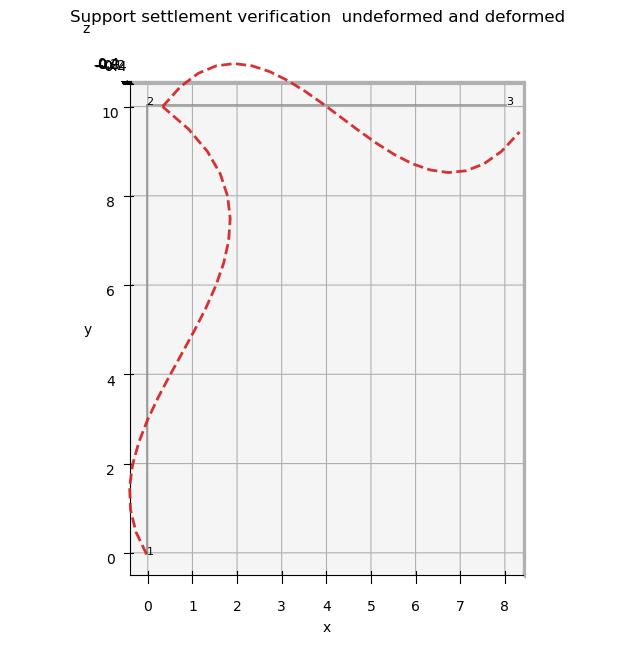

In [171]:
import importlib
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import helpers.plotting_simple as ps
    importlib.reload(ps)
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import plotting_simple as ps
    importlib.reload(ps)
    from plotting_simple import plot_structure_simple

fig, ax = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=60.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=True,
    show_element_labels=False,
    title="Support settlement verification  undeformed and deformed",
    view="xy",
    save_path="outputs/validation/simple_plots/verification_support_settlement_frame.png",
)

In [172]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)
    from plotting_plotly import plot_structure_plotly

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=60.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_member_loads=True,
    member_load_scale=0.02,
    title="Support settlement verification interactive",
    save_html="outputs/validation/plotly_plots/verification_support_settlement_frame.html",
    save_png="outputs/validation/plotly_plots/verification_support_settlement_frame.png",
)

fig.show()

In [173]:
import importlib
import numpy as np
import pandas as pd

try:
    import helpers.preprocess as prep
    import helpers.solver as solv

    importlib.reload(prep)
    importlib.reload(solv)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    import preprocess as prep
    import solver as solv

    importlib.reload(prep)
    importlib.reload(solv)

    from preprocess import preprocess_model
    from solver import solve_complete_model

model_path = "inputs/validation/Validation files from previous examples/verification_support_settlement_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

labels = []
for node_id in sorted(clean_model["nodes"].keys()):
    dof_map = data["node_dof_map"][node_id]
    for dof_name, gdof in dof_map.items():
        labels.append((gdof, node_id, dof_name))

label_map = {gdof: (node_id, dof_name) for gdof, node_id, dof_name in labels}

res = package["results"]
K_fr = res["K_fr"]
Ur = res["Ur"]
restrained = data["restrained_dofs"]
free = data["free_dofs"]

rows = []
for i, gdof in enumerate(restrained):
    node_id, dof_name = label_map[gdof]
    rows.append({
        "restrained_index": i,
        "global_dof_0based": gdof,
        "node": node_id,
        "dof": dof_name,
        "Ur_value": Ur[i],
    })

df_ur = pd.DataFrame(rows)

term = K_fr @ Ur
rhs = res["Ff"] - term + res["FEFf"]

df_term = pd.DataFrame({
    "free_index": range(len(free)),
    "global_dof_0based": free,
    "node": [label_map[g][0] for g in free],
    "dof": [label_map[g][1] for g in free],
    "Kfr_Ur": term,
    "Ff": res["Ff"],
    "FEFf": res["FEFf"],
    "rhs_recomputed": rhs,
    "Uf": res["Uf"],
})

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("\nRestrained DOF order and prescribed values\n")
print(df_ur.to_string(index=False))

print("\nFree DOF support-motion term\n")
print(df_term.to_string(index=False))


Restrained DOF order and prescribed values

 restrained_index  global_dof_0based  node dof  Ur_value
                0                  0     1  ux     0.000
                1                  1     1  uy     0.000
                2                  2     1  uz     0.000
                3                  3     1  rx     0.000
                4                  4     1  ry     0.000
                5                  5     1  rz     0.010
                6                  8     2  uz     0.000
                7                  9     2  rx     0.000
                8                 10     2  ry     0.000
                9                 12     3  ux     0.005
               10                 13     3  uy    -0.010
               11                 14     3  uz     0.000
               12                 15     3  rx     0.000
               13                 16     3  ry     0.000

Free DOF support-motion term

 free_index  global_dof_0based  node dof      Kfr_Ur  Ff   FEFf  rhs_

In [174]:
print(tables["support_reactions"].to_string(index=False))
print()
print(tables["element_local_end_forces"].to_string(index=False))

 node_id   x    y   z          Rx        Ry  Rz  Mx  My         Mz  reaction_force_mag  reaction_moment_mag
       1 0.0  0.0 0.0 -128.793081 56.348349 0.0 0.0 0.0 238.717605          140.580206           238.717605
       2 0.0 10.0 0.0    0.000000  0.000000 0.0 0.0 0.0   0.000000            0.000000             0.000000
       3 8.0 10.0 0.0 -111.206919 18.651651 0.0 0.0 0.0   0.000000          112.760201             0.000000

 elem_id     type  node_i  node_j  Fx_i_local  Fy_i_local  Fz_i_local  Mx_i_local  My_i_local  Mz_i_local  Fx_j_local  Fy_j_local  Fz_j_local  Mx_j_local  My_j_local  Mz_j_local
       1 3D_frame       1       2   56.348349  128.793081         0.0         0.0         0.0  238.717605  -56.348349  111.206919         0.0         0.0         0.0 -150.786794
       2 3D_frame       2       3  111.206919   56.348349         0.0         0.0         0.0  150.786794 -111.206919   18.651651         0.0         0.0         0.0    0.000000


In [175]:
for resp in package["element_responses"]:
    print(f"\nElement {resp['elem_id']}")
    print("u_local_elem")
    print(resp["v_local_elem"])
    print("q_local_elem")
    print(resp["q_local_elem"])


Element 1
u_local_elem
[ 0.          0.          0.          0.          0.          0.01
 -0.00059439 -0.00593846  0.          0.          0.          0.02181937]
q_local_elem
[  56.34834923  128.79308115    0.            0.            0.
  238.71760529  -56.34834923  111.20691885    0.            0.
    0.         -150.78679383]

Element 2
u_local_elem
[ 0.00593846 -0.00059439  0.          0.          0.          0.02181937
  0.005      -0.01        0.          0.          0.          0.02111055]
q_local_elem
[ 111.20691885   56.34834923    0.            0.            0.
  150.78679383 -111.20691885   18.65165077    0.            0.
    0.            0.        ]


In [176]:
import importlib
import numpy as np

try:
    import helpers.elements_3d as e3d
    importlib.reload(e3d)
    from helpers.elements_3d import k_local_3d_frame, get_element_fixed_end_force_local
except ImportError:
    import elements_3d as e3d
    importlib.reload(e3d)
    from elements_3d import k_local_3d_frame, get_element_fixed_end_force_local

for resp in package["element_responses"]:
    elem_id = resp["elem_id"]
    v_local = resp["v_local_elem"]
    q_local = resp["q_local_elem"]

    k_local = k_local_3d_frame(clean_model, elem_id)
    qf_local = get_element_fixed_end_force_local(clean_model, elem_id)
    ku_local = k_local @ v_local

    print(f"\nElement {elem_id}")
    print("v_local")
    print(np.array2string(v_local, precision=6, suppress_small=False))
    print()
    print("k_local @ v_local")
    print(np.array2string(ku_local, precision=6, suppress_small=False))
    print()
    print("qf_local")
    print(np.array2string(qf_local, precision=6, suppress_small=False))
    print()
    print("q_local = ku_local + qf_local")
    print(np.array2string(q_local, precision=6, suppress_small=False))


Element 1
v_local
[ 0.        0.        0.        0.        0.        0.01     -0.000594
 -0.005938  0.        0.        0.        0.021819]

k_local @ v_local
[ 56.348349   8.793081   0.         0.         0.        38.717605
 -56.348349  -8.793081   0.         0.         0.        49.213206]

qf_local
[   0.  120.    0.    0.    0.  200.    0.  120.    0.    0.    0. -200.]

q_local = ku_local + qf_local
[  56.348349  128.793081    0.          0.          0.        238.717605
  -56.348349  111.206919    0.          0.          0.       -150.786794]

Element 2
v_local
[ 0.005938 -0.000594  0.        0.        0.        0.021819  0.005
 -0.01      0.        0.        0.        0.021111]

k_local @ v_local
[ 111.206919   18.848349    0.          0.          0.         75.786794
 -111.206919  -18.848349    0.          0.          0.         75.      ]

qf_local
[  0.   37.5   0.    0.    0.   75.    0.   37.5   0.    0.    0.  -75. ]

q_local = ku_local + qf_local
[ 111.206919   56.3483